# DINOv2 Weed Classifier — Inference Notebook

This notebook wraps `infer_dinov2.py` and supports three modes:

| Mode | Description |
|------|-------------|
| **Single image** | Predict one image and show top-5 class probabilities |
| **Directory** | Batch-predict a flat folder of images (no ground truth) |
| **Labelled test set** | ImageFolder-style dataset — compute accuracy, confusion matrix, and misclassification analysis |

Set your paths in the **Configuration** cell, then run all cells from top to bottom.

## 1. Imports

In [1]:
import csv
import os
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
from PIL import Image, ImageDraw, ImageFont, ImageOps

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Make sure the dinov2 submodule is importable
sys.path.append('/content/')
SCRIPT_DIR = Path(".").resolve()
sys.path.insert(0, str(SCRIPT_DIR / "dinov2"))
from dinov2.models.vision_transformer import vit_base

print("Imports OK")

Imports OK


/home/ghosn/Project/assignment/cvs/hw4/dinov2/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/ghosn/Project/assignment/cvs/hw4/dinov2/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/ghosn/Project/assignment/cvs/hw4/dinov2/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


## 2. Configuration — **edit here**

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────
BUNDLE_PATH       = "output_stage1/stage1_bundle.pth"
BACKBONE_WEIGHTS  = "weight/dinov2_vitb14_pretrain.pth"

# ── Inference mode ────────────────────────────────────────────────────
# Options: "single" | "directory" | "labelled"
MODE = "labelled"

# Path to image / directory / ImageFolder root
INPUT_PATH = "data/test"

# ── Optional outputs ──────────────────────────────────────────────────
SAVE_CSV        = "predictions.csv"   # set to None to skip
SAVE_CM         = "confusion_matrix.csv"  # set to None to auto-name
SAVE_ERROR_DIR  = "error_analysis"    # set to None to auto-name
MAX_ERROR_EXAMPLES = 12

# ── Dataloader ────────────────────────────────────────────────────────
BATCH_SIZE  = 64
NUM_WORKERS = 4

# ── Device ────────────────────────────────────────────────────────────
DEVICE_STR = "cuda"   # falls back to cpu automatically

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

## 3. Model definitions (must match training)

In [3]:
class AttentionPoolingHead(nn.Module):
    """CLS token + attention-pooled patch tokens → MLP classifier."""

    def __init__(self, embed_dim: int, num_classes: int,
                 hidden_dim: int = 512, num_heads: int = 4, dropout: float = 0.3):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.attn_norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim * 2),
            nn.Linear(embed_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, cls_token, patch_tokens):
        B = cls_token.shape[0]
        q = self.query.expand(B, -1, -1)
        pooled, _ = self.attn(q, patch_tokens, patch_tokens)
        pooled = self.attn_norm(pooled.squeeze(1))
        fused = torch.cat([cls_token, pooled], dim=1)
        return self.classifier(fused)


def _build_head(head_type: str, embed_dim: int, num_classes: int) -> nn.Module:
    if head_type == "linear":
        return nn.Linear(embed_dim, num_classes)
    if head_type == "mlp":
        return nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
    if head_type == "attn_pool":
        return AttentionPoolingHead(embed_dim, num_classes)
    raise ValueError(f"Unknown head type: {head_type}")


def _forward_head(head, backbone_out):
    if isinstance(head, AttentionPoolingHead):
        return head(backbone_out["x_norm_clstoken"], backbone_out["x_norm_patchtokens"])
    return head(backbone_out["x_norm_clstoken"])


print("Head definitions ready")

Head definitions ready


## 4. Helper utilities

In [4]:
def build_transform(img_size: int = 224):
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    return transforms.Compose([
        transforms.Resize(int(img_size * 256 / 224)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])


class ImageListDataset(Dataset):
    """Dataset for a flat list of image paths (no labels)."""
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), str(self.paths[idx])


def _load_thumb(image_path, size=(224, 224)):
    img = Image.open(image_path).convert("RGB")
    return ImageOps.fit(img, size, method=Image.Resampling.LANCZOS)


def _find_support_example(samples, class_to_idx, class_name, exclude_path=None):
    class_idx = class_to_idx.get(class_name)
    if class_idx is None:
        return None
    for sample_path, sample_label in samples:
        if sample_label == class_idx and sample_path != exclude_path:
            return sample_path
    return None


def _get_error_dir(save_error_dir, save_csv):
    if save_error_dir:
        return Path(save_error_dir)
    if save_csv:
        return Path(save_csv).with_name(f"{Path(save_csv).stem}_error_analysis")
    return Path.cwd() / "error_analysis"


print("Utilities ready")

Utilities ready


## 5. Load model

In [5]:
device = torch.device(DEVICE_STR if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Load bundle ───────────────────────────────────────────────────────
bundle = torch.load(BUNDLE_PATH, map_location="cpu", weights_only=False)
print(f"Bundle loaded  |  head_type={bundle['head_type']}  "
      f"embed_dim={bundle['embed_dim']}  num_classes={bundle['num_classes']}")
class_names = bundle["class_names"]
print(f"Classes ({len(class_names)}): {class_names}")

# ── Build backbone ────────────────────────────────────────────────────
backbone = vit_base(patch_size=14, img_size=518, block_chunks=0, init_values=1e-5)
state = torch.load(BACKBONE_WEIGHTS, map_location="cpu", weights_only=True)
backbone.load_state_dict(state, strict=True)
backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False
backbone.to(device)
print("Backbone loaded")

# ── Build head ────────────────────────────────────────────────────────
head = _build_head(bundle["head_type"], bundle["embed_dim"], bundle["num_classes"])
head.load_state_dict(bundle["head_state_dict"])
head.eval()
head.to(device)
print("Classification head loaded")

tf = build_transform(img_size=224)

Using device: cuda
Bundle loaded  |  head_type=attn_pool  embed_dim=768  num_classes=10
Classes (10): ['Carpetweed', 'Eclipta', 'Goosegrass', 'Morningglory', 'Nutsedge', 'PalmerAmaranth', 'Purslane', 'Sicklepod', 'SpottedSpurge', 'Waterhemp']
Backbone loaded
Classification head loaded


## 6. Quick-test — single specific image

Set `TEST_IMAGE_PATH` to any image file and run this cell independently of `MODE`.  
The model must already be loaded (section 5).

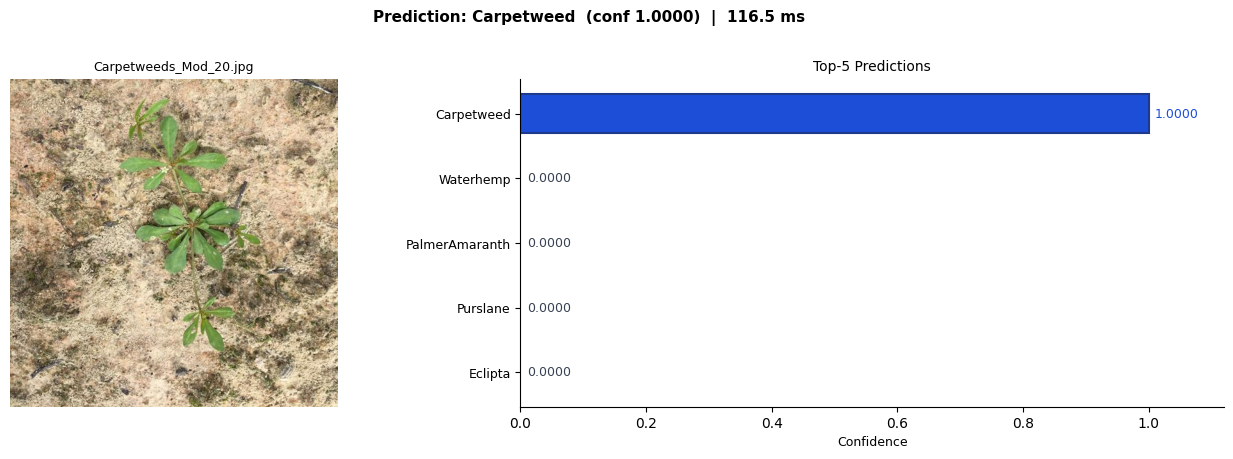


Image : data/test/Carpetweed-compet/Carpetweeds_Mod_20.jpg
Time  : 116.51 ms

Rank   Class                     Confidence
────────────────────────────────────────────
1      Carpetweed                    1.0000 ◀
2      Waterhemp                     0.0000
3      PalmerAmaranth                0.0000
4      Purslane                      0.0000
5      Eclipta                       0.0000


In [6]:
# ── Set the path to the image you want to test ───────────────────────
TEST_IMAGE_PATH = "data/test/Carpetweed-compet/Carpetweeds_Mod_20.jpg"  # ← change me

# ─────────────────────────────────────────────────────────────────────
assert os.path.isfile(TEST_IMAGE_PATH), f"File not found: {TEST_IMAGE_PATH}"

img_orig = Image.open(TEST_IMAGE_PATH).convert("RGB")
x = tf(img_orig).unsqueeze(0).to(device)

t0 = time.time()
with torch.no_grad():
    features = backbone.forward_features(x)
    logits   = _forward_head(head, features)
elapsed_ms = (time.time() - t0) * 1000

probs    = torch.softmax(logits, dim=1).squeeze().cpu()
top_k    = probs.topk(min(5, len(class_names)))
top_probs  = top_k.values.numpy()
top_labels = [class_names[i] for i in top_k.indices.numpy()]

# ── display ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1, 1.6]})

axes[0].imshow(img_orig)
axes[0].axis("off")
axes[0].set_title(Path(TEST_IMAGE_PATH).name, fontsize=9, pad=6)

# confidence bar chart
bar_colors = ["#1d4ed8" if i == 0 else "#93c5fd" for i in range(len(top_probs))]
bars = axes[1].barh(range(len(top_probs)), top_probs, color=bar_colors, edgecolor="white", height=0.6)
axes[1].set_yticks(range(len(top_labels)))
axes[1].set_yticklabels(top_labels, fontsize=9)
axes[1].set_xlabel("Confidence", fontsize=9)
axes[1].set_xlim(0, 1.12)
axes[1].set_title("Top-5 Predictions", fontsize=10)
axes[1].invert_yaxis()
axes[1].spines[["top", "right"]].set_visible(False)

for bar, prob in zip(bars, top_probs):
    axes[1].text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{prob:.4f}",
        va="center", fontsize=9,
        color="#1d4ed8" if prob == top_probs[0] else "#374151",
    )

# add a coloured border around top-1 bar
bars[0].set_linewidth(1.5)
bars[0].set_edgecolor("#1e3a8a")

plt.suptitle(
    f"Prediction: {top_labels[0]}  (conf {top_probs[0]:.4f})  |  {elapsed_ms:.1f} ms",
    fontsize=11, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# ── text summary ─────────────────────────────────────────────────────
print(f"\nImage : {TEST_IMAGE_PATH}")
print(f"Time  : {elapsed_ms:.2f} ms")
print(f"\n{'Rank':<6} {'Class':<25} {'Confidence':>10}")
print("─" * 44)
for rank, (lbl, prob) in enumerate(zip(top_labels, top_probs), 1):
    marker = " ◀" if rank == 1 else ""
    print(f"{rank:<6} {lbl:<25} {prob:>10.4f}{marker}")

## 7. Batch / Labelled Inference

The cells below dispatch to the appropriate mode based on `MODE` and `INPUT_PATH`.

### 7a. Single-image inference

In [7]:
def infer_single_image(img_path):
    """Predict one image; display the image and a top-5 probability bar chart."""
    img = Image.open(img_path).convert("RGB")
    x = tf(img).unsqueeze(0).to(device)

    t0 = time.time()
    with torch.no_grad():
        features = backbone.forward_features(x)
        logits = _forward_head(head, features)
    elapsed_ms = (time.time() - t0) * 1000

    probs = torch.softmax(logits, dim=1).squeeze().cpu()
    top5 = probs.topk(min(5, len(class_names)))
    top_probs = top5.values.numpy()
    top_labels = [class_names[i] for i in top5.indices.numpy()]

    # ── display ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(Path(img_path).name, fontsize=10)

    colors = ["#2563eb" if i == 0 else "#93c5fd" for i in range(len(top_probs))]
    bars = axes[1].barh(range(len(top_probs)), top_probs, color=colors)
    axes[1].set_yticks(range(len(top_labels)))
    axes[1].set_yticklabels(top_labels, fontsize=9)
    axes[1].set_xlabel("Probability")
    axes[1].set_title("Top-5 Predictions")
    axes[1].set_xlim(0, 1)
    axes[1].invert_yaxis()
    for bar, prob in zip(bars, top_probs):
        axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                     f"{prob:.4f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f"Inference time: {elapsed_ms:.2f} ms   |   Top prediction: {top_labels[0]} ({top_probs[0]:.4f})")
    return top_labels, top_probs


if MODE == "single" or (MODE != "labelled" and os.path.isfile(INPUT_PATH)):
    infer_single_image(INPUT_PATH)
else:
    print("Skipping single-image inference (MODE is not 'single').")

Skipping single-image inference (MODE is not 'single').


### 7b. Directory inference (no ground-truth labels)

In [8]:
def infer_directory(dir_path, save_csv=None):
    """Batch-predict all images in a flat directory."""
    paths = sorted([
        p for p in Path(dir_path).rglob("*")
        if p.suffix.lower() in IMAGE_EXTENSIONS
    ])
    if not paths:
        print(f"No images found in {dir_path}")
        return None

    dataset = ImageListDataset(paths, tf)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

    all_paths, all_preds, all_confs = [], [], []
    total_time = 0.0

    with torch.no_grad():
        for imgs, img_paths in loader:
            imgs = imgs.to(device, non_blocking=True)
            t0 = time.time()
            features = backbone.forward_features(imgs)
            logits = _forward_head(head, features)
            total_time += time.time() - t0
            probs = torch.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)
            all_paths.extend(img_paths)
            all_preds.extend(preds.cpu().tolist())
            all_confs.extend(confs.cpu().tolist())

    n = len(all_paths)
    print(f"Processed {n} images | avg {total_time/n*1000:.2f} ms / image")

    # ── summary bar chart ─────────────────────────────────────────────
    pred_labels = [class_names[p] for p in all_preds]
    counts = Counter(pred_labels)
    sorted_classes = sorted(counts, key=counts.get, reverse=True)

    fig, ax = plt.subplots(figsize=(max(8, len(sorted_classes) * 0.6), 4))
    ax.bar(sorted_classes, [counts[c] for c in sorted_classes], color="#2563eb")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_title(f"Prediction distribution — {n} images")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()

    if save_csv:
        with open(save_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["image", "prediction", "confidence"])
            for path, pred, conf in zip(all_paths, all_preds, all_confs):
                w.writerow([os.path.basename(path), class_names[pred], f"{conf:.4f}"])
        print(f"Predictions saved to {save_csv}")

    return all_paths, all_preds, all_confs


if MODE == "directory":
    infer_directory(INPUT_PATH, save_csv=SAVE_CSV)
else:
    print("Skipping directory inference (MODE is not 'directory').")

Skipping directory inference (MODE is not 'directory').


### 7c. Labelled test-set inference (accuracy + confusion matrix)

In [9]:
def infer_with_labels(dir_path, save_csv=None, save_cm=None,
                      save_error_dir=None, max_error_examples=12):
    from sklearn.metrics import classification_report, confusion_matrix

    test_dataset = datasets.ImageFolder(dir_path, transform=tf)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    test_class_names = test_dataset.classes

    # Map test-folder indices → training class indices
    test_to_train = {}
    for tidx, tname in enumerate(test_class_names):
        base = tname.replace("-compet", "")
        if base in class_names:
            test_to_train[tidx] = class_names.index(base)
        else:
            print(f"  WARNING: test class '{tname}' has no train match — mapping by index")
            test_to_train[tidx] = tidx

    all_preds, all_gt, all_confs = [], [], []
    total_time = 0.0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device, non_blocking=True)
            t0 = time.time()
            features = backbone.forward_features(imgs)
            logits = _forward_head(head, features)
            total_time += time.time() - t0
            probs = torch.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)
            for pred, conf, label in zip(preds.cpu(), confs.cpu(), labels):
                mapped = test_to_train.get(label.item(), label.item())
                all_gt.append(mapped)
                all_preds.append(pred.item())
                all_confs.append(conf.item())

    all_paths = [s[0] for s in test_dataset.samples]
    n = len(all_gt)
    correct = sum(p == g for p, g in zip(all_preds, all_gt))
    avg_ms = (total_time / n) * 1000

    print(f"\n{'='*70}")
    print(f"Test set : {dir_path}  ({n} images)")
    print(f"Accuracy : {correct/n:.4f}  ({correct}/{n})")
    print(f"Avg time : {avg_ms:.2f} ms / image")
    print(f"{'='*70}\n")

    print("Per-class report:")
    print(classification_report(all_gt, all_preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_gt, all_preds)
    return all_paths, all_preds, all_gt, all_confs, cm, test_dataset


results = None
if MODE == "labelled":
    results = infer_with_labels(
        INPUT_PATH,
        save_csv=SAVE_CSV,
        save_cm=SAVE_CM,
        save_error_dir=SAVE_ERROR_DIR,
        max_error_examples=MAX_ERROR_EXAMPLES,
    )
else:
    print("Skipping labelled inference (MODE is not 'labelled').")


Test set : data/test  (164 images)
Accuracy : 0.9878  (162/164)
Avg time : 0.12 ms / image

Per-class report:
                precision    recall  f1-score   support

    Carpetweed       1.00      1.00      1.00        20
       Eclipta       1.00      1.00      1.00        15
    Goosegrass       1.00      1.00      1.00        12
  Morningglory       1.00      1.00      1.00        20
      Nutsedge       1.00      1.00      1.00        14
PalmerAmaranth       0.91      1.00      0.95        20
      Purslane       1.00      1.00      1.00        16
     Sicklepod       1.00      0.93      0.97        15
 SpottedSpurge       1.00      0.92      0.96        13
     Waterhemp       1.00      1.00      1.00        19

      accuracy                           0.99       164
     macro avg       0.99      0.99      0.99       164
  weighted avg       0.99      0.99      0.99       164



## 8. Confusion matrix visualisation

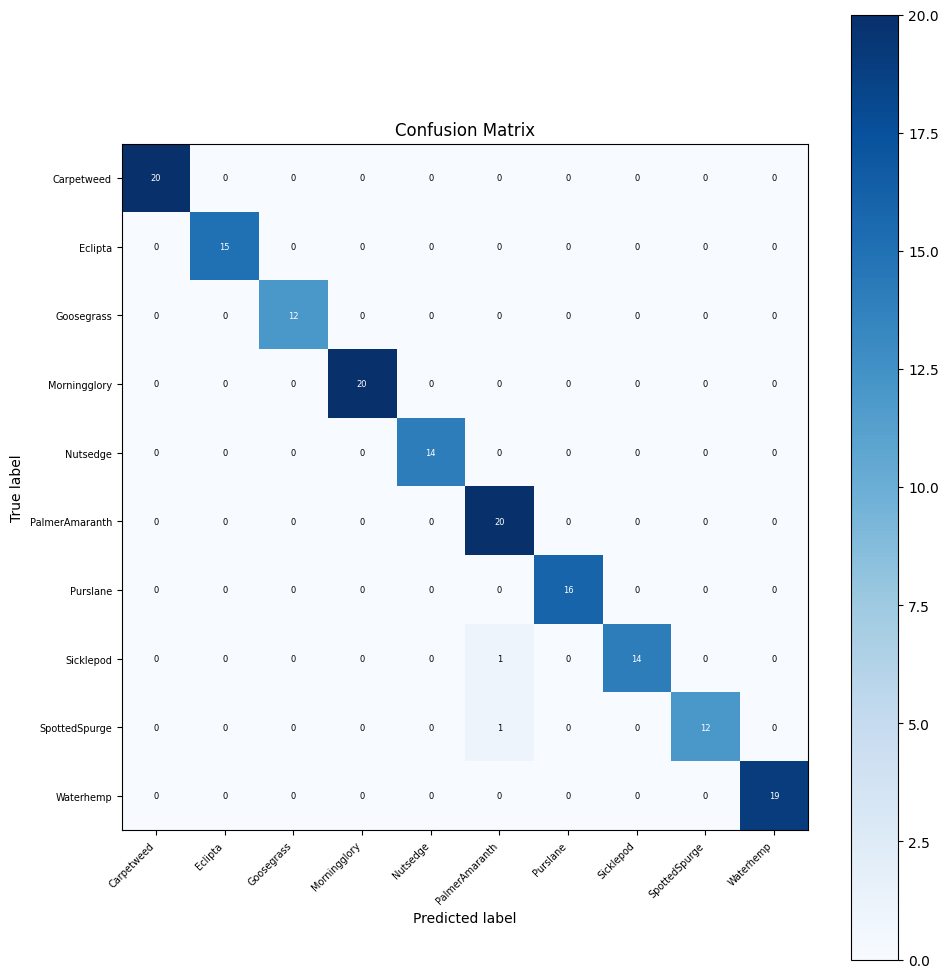

Confusion matrix saved to confusion_matrix.csv


In [10]:
if results is not None:
    all_paths, all_preds, all_gt, all_confs, cm, test_dataset = results

    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(7, len(class_names))))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(class_names, fontsize=7)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    ax.set_title("Confusion Matrix")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center", fontsize=6,
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

    # ── save CSV ──────────────────────────────────────────────────────
    cm_path = Path(SAVE_CM) if SAVE_CM else Path("confusion_matrix.csv")
    with open(cm_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["true/pred"] + class_names)
        for cls, row in zip(class_names, cm.tolist()):
            writer.writerow([cls] + row)
    print(f"Confusion matrix saved to {cm_path}")
else:
    print("No labelled results available.")

## 9. Per-class accuracy bar chart

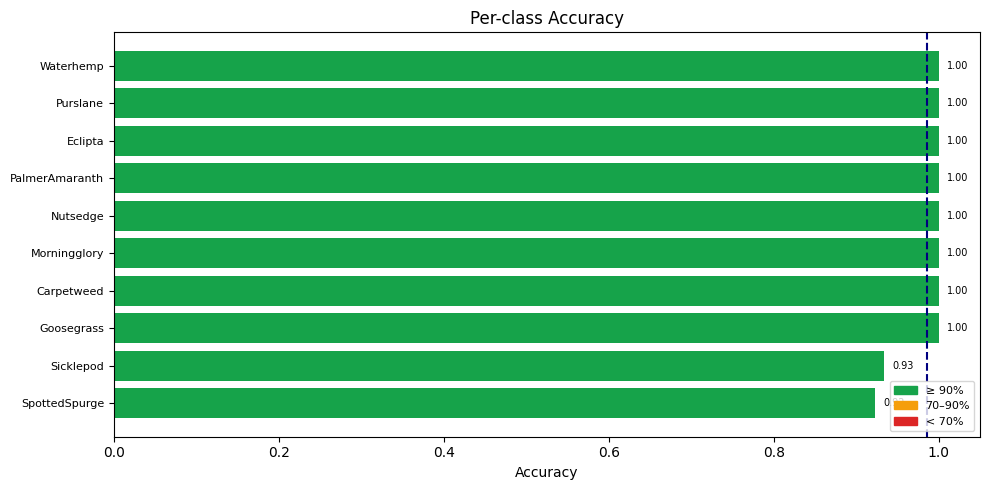

In [11]:
if results is not None:
    all_paths, all_preds, all_gt, all_confs, cm, test_dataset = results

    per_class_correct = np.diag(cm)
    per_class_total   = cm.sum(axis=1)
    per_class_acc     = np.where(per_class_total > 0,
                                  per_class_correct / per_class_total, 0.0)

    sorted_idx = np.argsort(per_class_acc)
    sorted_acc    = per_class_acc[sorted_idx]
    sorted_labels = [class_names[i] for i in sorted_idx]

    fig, ax = plt.subplots(figsize=(10, max(5, len(class_names) * 0.4)))
    colors = ["#16a34a" if a >= 0.9 else ("#f59e0b" if a >= 0.7 else "#dc2626")
              for a in sorted_acc]
    ax.barh(range(len(sorted_labels)), sorted_acc, color=colors)
    ax.set_yticks(range(len(sorted_labels)))
    ax.set_yticklabels(sorted_labels, fontsize=8)
    ax.set_xlabel("Accuracy")
    ax.set_xlim(0, 1.05)
    ax.set_title("Per-class Accuracy")
    ax.axvline(per_class_acc.mean(), color="navy", linestyle="--", label=f"mean={per_class_acc.mean():.3f}")
    ax.legend(fontsize=8)

    legend_patches = [
        mpatches.Patch(color="#16a34a", label="≥ 90%"),
        mpatches.Patch(color="#f59e0b", label="70–90%"),
        mpatches.Patch(color="#dc2626", label="< 70%"),
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc="lower right")

    for i, acc in enumerate(sorted_acc):
        ax.text(acc + 0.01, i, f"{acc:.2f}", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()
else:
    print("No labelled results available.")

## 10. Misclassification analysis

In [12]:
def save_misclassification_analysis(misclassified, test_dataset, error_dir, max_error_examples):
    error_dir.mkdir(parents=True, exist_ok=True)
    summary_txt_path = error_dir / "misclassification_summary.txt"
    summary_csv_path = error_dir / "misclassification_details.csv"
    collage_path     = error_dir / "misclassified_grid.png"
    pair_dir         = error_dir / "pair_analysis"
    pair_dir.mkdir(parents=True, exist_ok=True)

    pair_counts          = Counter((item["ground_truth"], item["prediction"]) for item in misclassified)
    class_error_counts   = Counter(item["ground_truth"] for item in misclassified)
    avg_conf_by_pair     = {}
    for pair in pair_counts:
        confidences = [item["confidence"] for item in misclassified
                       if (item["ground_truth"], item["prediction"]) == pair]
        avg_conf_by_pair[pair] = sum(confidences) / len(confidences)

    with open(summary_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["image", "true_class", "predicted_class", "confidence"])
        for item in misclassified:
            writer.writerow([os.path.basename(item["path"]), item["ground_truth"],
                             item["prediction"], f"{item['confidence']:.4f}"])

    with open(summary_txt_path, "w") as f:
        f.write(f"Total misclassified: {len(misclassified)}\n\n")
        f.write("Errors by true class:\n")
        for cls, count in class_error_counts.most_common():
            f.write(f"  - {cls}: {count}\n")
        f.write("\nMost common confusion pairs:\n")
        for (true_name, pred_name), count in pair_counts.most_common():
            f.write(f"  - {true_name} -> {pred_name}: {count} "
                    f"(avg conf {avg_conf_by_pair[(true_name, pred_name)]:.4f})\n")

    font = ImageFont.load_default()
    selected = sorted(misclassified, key=lambda x: x["confidence"])[:max_error_examples]
    if selected:
        cols = min(3, len(selected))
        rows = (len(selected) + cols - 1) // cols
        tile_w, tile_h = 300, 340
        canvas = Image.new("RGB", (cols * tile_w, rows * tile_h), color=(248, 250, 252))
        for idx, item in enumerate(selected):
            col, row = idx % cols, idx // cols
            x0, y0 = col * tile_w, row * tile_h
            thumb = _load_thumb(item["path"], size=(260, 220))
            canvas.paste(thumb, (x0 + 20, y0 + 16))
            draw = ImageDraw.Draw(canvas)
            y_txt = y0 + 250
            for line in [os.path.basename(item["path"]),
                         f"True: {item['ground_truth']}",
                         f"Pred: {item['prediction']}",
                         f"Conf: {item['confidence']:.4f}"]:
                draw.text((x0 + 20, y_txt), line, font=font, fill=(17, 24, 39))
                bbox = draw.textbbox((x0 + 20, y_txt), line, font=font)
                y_txt = bbox[3] + 4
        canvas.save(collage_path)

    grouped = defaultdict(list)
    for item in misclassified:
        grouped[(item["ground_truth"], item["prediction"])].append(item)

    for pair_rank, ((true_name, pred_name), pair_count) in enumerate(pair_counts.most_common(5), start=1):
        pair_items = grouped[(true_name, pred_name)]
        example   = sorted(pair_items, key=lambda x: x["confidence"])[0]
        true_ref  = _find_support_example(test_dataset.samples, test_dataset.class_to_idx, true_name, exclude_path=example["path"])
        pred_ref  = _find_support_example(test_dataset.samples, test_dataset.class_to_idx, pred_name)

        panel = Image.new("RGB", (980, 330), color=(255, 255, 255))
        draw  = ImageDraw.Draw(panel)
        draw.rectangle((0, 0, 979, 329), outline=(203, 213, 225), width=2)
        draw.text((22, 16), f"Confusion #{pair_rank}: {true_name} -> {pred_name}  (count={pair_count})",
                  font=font, fill=(15, 23, 42))
        for title, image_path, (x0, y0) in [
            ("Misclassified sample", example["path"], (20, 55)),
            (f"Reference: true class ({true_name})", true_ref, (340, 55)),
            (f"Reference: predicted class ({pred_name})", pred_ref, (660, 55)),
        ]:
            draw.text((x0, y0), title, font=font, fill=(30, 41, 59))
            if image_path and os.path.exists(image_path):
                panel.paste(_load_thumb(image_path, size=(260, 220)), (x0, y0 + 24))
            else:
                draw.rectangle((x0, y0 + 24, x0 + 260, y0 + 244), outline=(148, 163, 184), width=2)
                draw.text((x0 + 76, y0 + 128), "No image", font=font, fill=(100, 116, 139))
        safe_name = f"{pair_rank:02d}_{true_name}_to_{pred_name}".replace("/", "_").replace(" ", "_")
        panel.save(pair_dir / f"{safe_name}.png")

    print(f"Misclassification analysis saved to {error_dir}")


if results is not None:
    all_paths, all_preds, all_gt, all_confs, cm, test_dataset = results
    n = len(all_gt)

    misclassified = [
        {
            "path": all_paths[i],
            "ground_truth": class_names[all_gt[i]],
            "prediction":   class_names[all_preds[i]],
            "confidence":   all_confs[i],
        }
        for i in range(n) if all_preds[i] != all_gt[i]
    ]
    print(f"Total misclassified: {len(misclassified)} / {n}")

    if misclassified:
        pair_counts = Counter((item["ground_truth"], item["prediction"]) for item in misclassified)
        print("\nTop-5 confusion pairs:")
        for (true_name, pred_name), count in pair_counts.most_common(5):
            avg_conf = sum(item["confidence"] for item in misclassified
                           if item["ground_truth"] == true_name and item["prediction"] == pred_name) / count
            print(f"  {true_name:20s} → {pred_name:20s}  count={count}  avg_conf={avg_conf:.4f}")

        error_dir = _get_error_dir(SAVE_ERROR_DIR, SAVE_CSV)
        save_misclassification_analysis(misclassified, test_dataset, error_dir, MAX_ERROR_EXAMPLES)
else:
    print("No labelled results available.")

Total misclassified: 2 / 164

Top-5 confusion pairs:
  Sicklepod            → PalmerAmaranth        count=1  avg_conf=0.5648
  SpottedSpurge        → PalmerAmaranth        count=1  avg_conf=0.6580
Misclassification analysis saved to error_analysis


## 11. Show misclassified grid (inline)

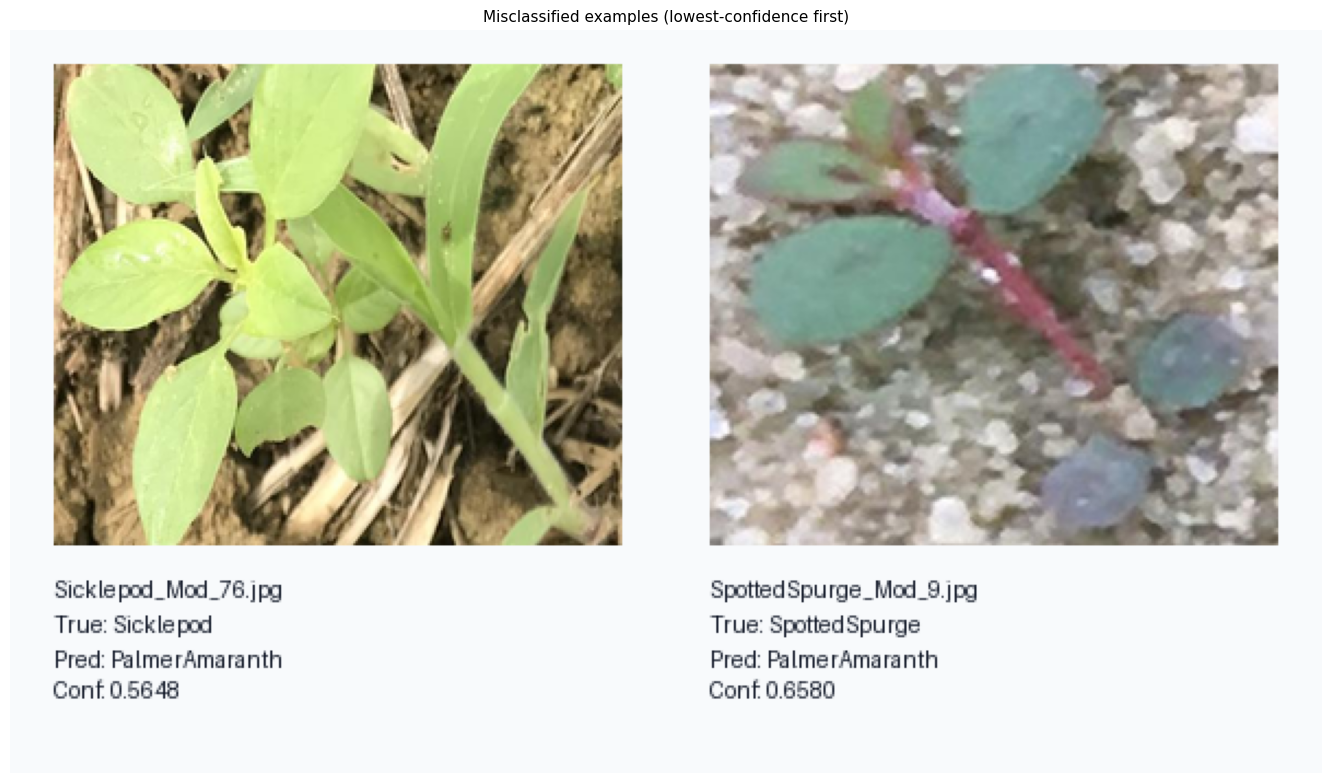

In [13]:
if results is not None:
    error_dir_path = _get_error_dir(SAVE_ERROR_DIR, SAVE_CSV)
    collage_path   = error_dir_path / "misclassified_grid.png"
    if collage_path.exists():
        grid_img = Image.open(collage_path)
        fig, ax = plt.subplots(figsize=(14, grid_img.height / grid_img.width * 14))
        ax.imshow(grid_img)
        ax.axis("off")
        ax.set_title("Misclassified examples (lowest-confidence first)", fontsize=11)
        plt.tight_layout()
        plt.show()
    else:
        print("No misclassification grid found (either no errors or analysis not run).")
else:
    print("No labelled results available.")

## 12. Save predictions CSV

In [14]:
if results is not None and SAVE_CSV:
    all_paths, all_preds, all_gt, all_confs, cm, test_dataset = results
    n = len(all_gt)
    with open(SAVE_CSV, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["image", "ground_truth", "prediction", "confidence", "correct"])
        for i in range(n):
            w.writerow([
                os.path.basename(all_paths[i]),
                class_names[all_gt[i]],
                class_names[all_preds[i]],
                f"{all_confs[i]:.4f}",
                all_preds[i] == all_gt[i],
            ])
    print(f"Predictions saved to {SAVE_CSV}")
elif SAVE_CSV is None:
    print("SAVE_CSV is None — skipping CSV export.")

Predictions saved to predictions.csv
